In [4]:
import pandas as pd

beauty = pd.read_csv(r"C:\Users\lahar\Downloads\Nykaa_Baby_Products.csv")
baby = pd.read_csv(r"C:\Users\lahar\Downloads\beauty csv.csv")

In [5]:
print(beauty.columns)
print(baby.columns)

Index(['Product Name', 'Original Price', 'Discounted Price', 'Discount',
       'Reviews'],
      dtype='object')
Index(['Product Name,Original Price,Discounted Price,Discount,Reviews'], dtype='object')


In [6]:
beauty["Category"] = "Beauty"
baby["Category"] = "Baby"

In [7]:
final_df = pd.concat(
    [beauty, baby],
    ignore_index=True
)

In [8]:
for col in ["Original Price", "Discounted Price"]:

    final_df[col] = (
        final_df[col]
        .astype(str)
        .str.replace("₹", "", regex=False)
        .str.replace(",", "", regex=False)
        .str.replace("?", "", regex=False)
    )

    final_df[col] = pd.to_numeric(
        final_df[col],
        errors="coerce"
    )

In [9]:
final_df["Reviews"] = (
    final_df["Reviews"]
    .astype(str)
    .str.extract(r'(\d+)')
)

final_df["Reviews"] = pd.to_numeric(
    final_df["Reviews"],
    errors="coerce"
)

In [10]:
final_df.drop_duplicates(
    subset="Product Name",
    inplace=True
)

In [11]:
final_df.isnull().sum()

Product Name                                                      1
Original Price                                                    9
Discounted Price                                                  1
Discount                                                          1
Reviews                                                           1
Category                                                          0
Product Name,Original Price,Discounted Price,Discount,Reviews    20
dtype: int64

In [12]:
final_df.to_csv(
    "Nykaa_Beauty_Baby_Final.csv",
    index=False
)

In [13]:
final_df.to_csv(
    "Nykaa_Beauty_Baby_Final.csv",
    index=False
)

In [14]:
import os
print(os.getcwd())

C:\Users\lahar\NYKA-DATA-ANALYSIS\ NOTE BOOK


In [15]:
final_df.head()

,Product Name,Original Price,Discounted Price,Discount,Reviews,Category,"Product Name,Original Price,Discounted Price,Discount,Reviews"
0,Flicka Silk Touch 3-In-1 Moisturizer Primer An...,899.0,809.0,10% Off,15405.0,Beauty,NaN
1,L'Oreal Paris Infallible 3-Second Setting Spra...,799.0,719.0,10% Off,7746.0,Beauty,NaN
2,ETUDE Dear Darling Water Gel Lip and Cheek Tin...,450.0,405.0,10% Off,22608.0,Beauty,NaN
3,M.A.C Studio Fix Fluid SPF 15 Soft Matte Found...,4000.0,3400.0,15% Off,686256.0,Beauty,NaN
4,Charlotte Tilbury Airbrush Flawless Setting Spray,NaN,3950.0,No Discount,10926.0,Beauty,NaN


In [16]:
final_df

,Product Name,Original Price,Discounted Price,Discount,Reviews,Category,"Product Name,Original Price,Discounted Price,Discount,Reviews"
0,Flicka Silk Touch 3-In-1 Moisturizer Primer An...,899.0,809.0,10% Off,15405.0,Beauty,NaN
1,L'Oreal Paris Infallible 3-Second Setting Spra...,799.0,719.0,10% Off,7746.0,Beauty,NaN
2,ETUDE Dear Darling Water Gel Lip and Cheek Tin...,450.0,405.0,10% Off,22608.0,Beauty,NaN
3,M.A.C Studio Fix Fluid SPF 15 Soft Matte Found...,4000.0,3400.0,15% Off,686256.0,Beauty,NaN
4,Charlotte Tilbury Airbrush Flawless Setting Spray,NaN,3950.0,No Discount,10926.0,Beauty,NaN
5,L'Oreal Paris Voluminous Panorama Waterproof M...,999.0,949.0,5% Off,2831.0,Beauty,NaN
6,MARS Dance Of Joy Eyeshadow Palette,299.0,284.0,5% Off,30234.0,Beauty,NaN
7,"Swiss Beauty 3 In 1 Eyeliner, Eyebrow Filler a...",429.0,322.0,25% Off,34914.0,Beauty,NaN
8,e.l.f. Cosmetics Power Grip Primer,NaN,1300.0,No Discount,6639.0,Beauty,NaN
9,PAC Beginner Basic Face & Eye Brush Kit - Stur...,1895.0,1800.0,5% Off,290.0,Beauty,NaN


In [17]:
# If Original Price is blank, use Discounted Price
final_df["Original Price"] = final_df["Original Price"].fillna(
    final_df["Discounted Price"]
)

# If Discounted Price is blank, use Original Price
final_df["Discounted Price"] = final_df["Discounted Price"].fillna(
    final_df["Original Price"]
)

In [18]:
final_df[["Original Price","Discounted Price"]].isnull().sum()

Original Price      1
Discounted Price    1
dtype: int64

In [19]:
final_df.to_csv(
    "Nykaa_Beauty_Baby_Final.csv",
    index=False
)

In [20]:
print(final_df.head(10))
print(final_df.columns)

                                        Product Name  Original Price  \
0  Flicka Silk Touch 3-In-1 Moisturizer Primer An...           899.0   
1  L'Oreal Paris Infallible 3-Second Setting Spra...           799.0   
2  ETUDE Dear Darling Water Gel Lip and Cheek Tin...           450.0   
3  M.A.C Studio Fix Fluid SPF 15 Soft Matte Found...          4000.0   
4  Charlotte Tilbury Airbrush Flawless Setting Spray          3950.0   
5  L'Oreal Paris Voluminous Panorama Waterproof M...           999.0   
6                MARS Dance Of Joy Eyeshadow Palette           299.0   
7  Swiss Beauty 3 In 1 Eyeliner, Eyebrow Filler a...           429.0   
8                 e.l.f. Cosmetics Power Grip Primer          1300.0   
9  PAC Beginner Basic Face & Eye Brush Kit - Stur...          1895.0   

   Discounted Price     Discount   Reviews Category  \
0             809.0      10% Off   15405.0   Beauty   
1             719.0      10% Off    7746.0   Beauty   
2             405.0      10% Off   22608.0

In [22]:
baby = pd.read_csv(r"C:\Users\lahar\Downloads\Nykaa_Baby_Products.csv")

In [23]:
print(baby.head())
print(baby.columns)

                                        Product Name Original Price  \
0  Flicka Silk Touch 3-In-1 Moisturizer Primer An...          ? 899   
1  L'Oreal Paris Infallible 3-Second Setting Spra...          ? 799   
2  ETUDE Dear Darling Water Gel Lip and Cheek Tin...          ? 450   
3  M.A.C Studio Fix Fluid SPF 15 Soft Matte Found...        ? 4,000   
4  Charlotte Tilbury Airbrush Flawless Setting Spray            NaN   

  Discounted Price     Discount  Reviews  
0            ? 809      10% Off   -15405  
1            ? 719      10% Off    -7746  
2            ? 405      10% Off   -22608  
3          ? 3,400      15% Off  -686256  
4          ? 3,950  No Discount   -10926  
Index(['Product Name', 'Original Price', 'Discounted Price', 'Discount',
       'Reviews'],
      dtype='object')


In [24]:
baby["Original Price"] = (
    baby["Original Price"]
    .astype(str)
    .str.replace("?", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)

baby["Discounted Price"] = (
    baby["Discounted Price"]
    .astype(str)
    .str.replace("?", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)

In [25]:
baby["Reviews"] = baby["Reviews"].abs()

In [26]:
baby["Reviews"] = baby["Reviews"].astype(int).abs()

In [27]:
baby["Original Price"] = baby["Original Price"].fillna(
    baby["Discounted Price"]
)

In [28]:
baby["Original Price"] = pd.to_numeric(
    baby["Original Price"],
    errors="coerce"
)

baby["Discounted Price"] = pd.to_numeric(
    baby["Discounted Price"],
    errors="coerce"
)

In [29]:
print(baby.head())
print(baby.info())

                                        Product Name  Original Price  \
0  Flicka Silk Touch 3-In-1 Moisturizer Primer An...           899.0   
1  L'Oreal Paris Infallible 3-Second Setting Spra...           799.0   
2  ETUDE Dear Darling Water Gel Lip and Cheek Tin...           450.0   
3  M.A.C Studio Fix Fluid SPF 15 Soft Matte Found...          4000.0   
4  Charlotte Tilbury Airbrush Flawless Setting Spray             NaN   

   Discounted Price     Discount  Reviews  
0               809      10% Off    15405  
1               719      10% Off     7746  
2               405      10% Off    22608  
3              3400      15% Off   686256  
4              3950  No Discount    10926  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Product Name      20 non-null     object 
 1   Original Price    12 non-null     float64
 2   Discount

In [30]:
beauty["Category"] = "Beauty"
baby["Category"] = "Baby"

final_df = pd.concat(
    [beauty, baby],
    ignore_index=True
)

In [31]:
final_df.to_csv(
    "Nykaa_Beauty_Baby_Final.csv",
    index=False
)

In [32]:
beauty.head()

,Product Name,Original Price,Discounted Price,Discount,Reviews,Category
0,Flicka Silk Touch 3-In-1 Moisturizer Primer An...,? 899,? 809,10% Off,-15405,Beauty
1,L'Oreal Paris Infallible 3-Second Setting Spra...,? 799,? 719,10% Off,-7746,Beauty
2,ETUDE Dear Darling Water Gel Lip and Cheek Tin...,? 450,? 405,10% Off,-22608,Beauty
3,M.A.C Studio Fix Fluid SPF 15 Soft Matte Found...,"? 4,000","? 3,400",15% Off,-686256,Beauty
4,Charlotte Tilbury Airbrush Flawless Setting Spray,NaN,"? 3,950",No Discount,-10926,Beauty


In [33]:
# Clean Original Price
final_df["Original Price"] = (
    final_df["Original Price"]
    .astype(str)
    .str.replace("?", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)

# Clean Discounted Price
final_df["Discounted Price"] = (
    final_df["Discounted Price"]
    .astype(str)
    .str.replace("?", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)

# Convert to numeric
final_df["Original Price"] = pd.to_numeric(
    final_df["Original Price"],
    errors="coerce"
)

final_df["Discounted Price"] = pd.to_numeric(
    final_df["Discounted Price"],
    errors="coerce"
)

# Fill missing Original Price
final_df["Original Price"] = final_df["Original Price"].fillna(
    final_df["Discounted Price"]
)

# Make Reviews positive
final_df["Reviews"] = final_df["Reviews"].abs()

In [34]:
final_df.head()

,Product Name,Original Price,Discounted Price,Discount,Reviews,Category
0,Flicka Silk Touch 3-In-1 Moisturizer Primer An...,899.0,809,10% Off,15405,Beauty
1,L'Oreal Paris Infallible 3-Second Setting Spra...,799.0,719,10% Off,7746,Beauty
2,ETUDE Dear Darling Water Gel Lip and Cheek Tin...,450.0,405,10% Off,22608,Beauty
3,M.A.C Studio Fix Fluid SPF 15 Soft Matte Found...,4000.0,3400,15% Off,686256,Beauty
4,Charlotte Tilbury Airbrush Flawless Setting Spray,3950.0,3950,No Discount,10926,Beauty


In [35]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Product Name      40 non-null     object 
 1   Original Price    40 non-null     float64
 2   Discounted Price  40 non-null     int64  
 3   Discount          40 non-null     object 
 4   Reviews           40 non-null     int64  
 5   Category          40 non-null     object 
dtypes: float64(1), int64(2), object(3)
memory usage: 2.0+ KB


In [36]:
final_df.isnull().sum()

Product Name        0
Original Price      0
Discounted Price    0
Discount            0
Reviews             0
Category            0
dtype: int64

In [37]:
final_df.to_csv("Nykaa_Beauty_Baby_Final.csv", index=False)

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

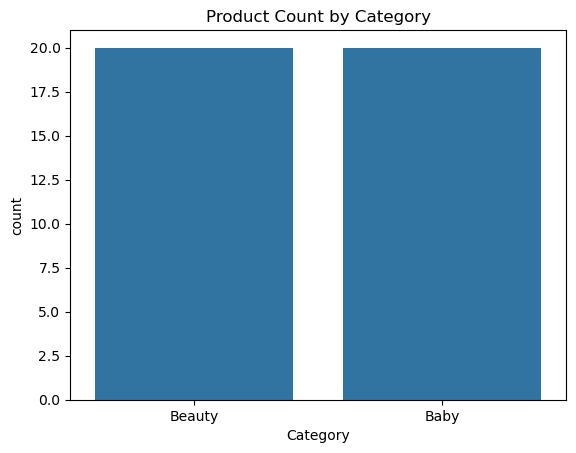

In [39]:
sns.countplot(x="Category", data=final_df)
plt.title("Product Count by Category")
plt.show()

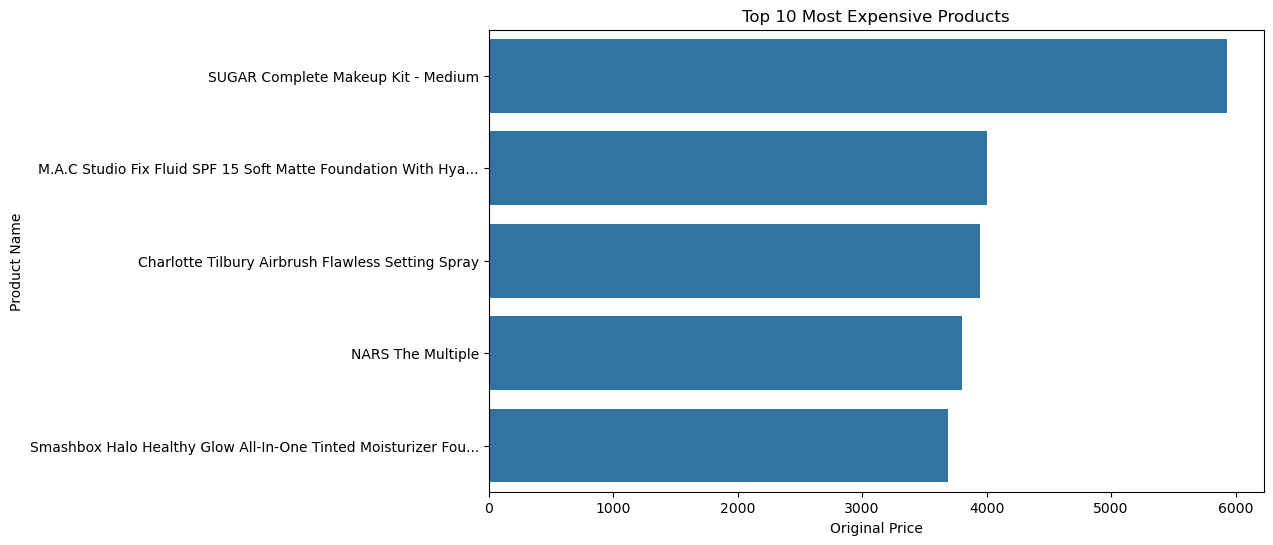

In [40]:
top10 = final_df.nlargest(10, "Original Price")

plt.figure(figsize=(10,6))
sns.barplot(data=top10, x="Original Price", y="Product Name")
plt.title("Top 10 Most Expensive Products")
plt.show()

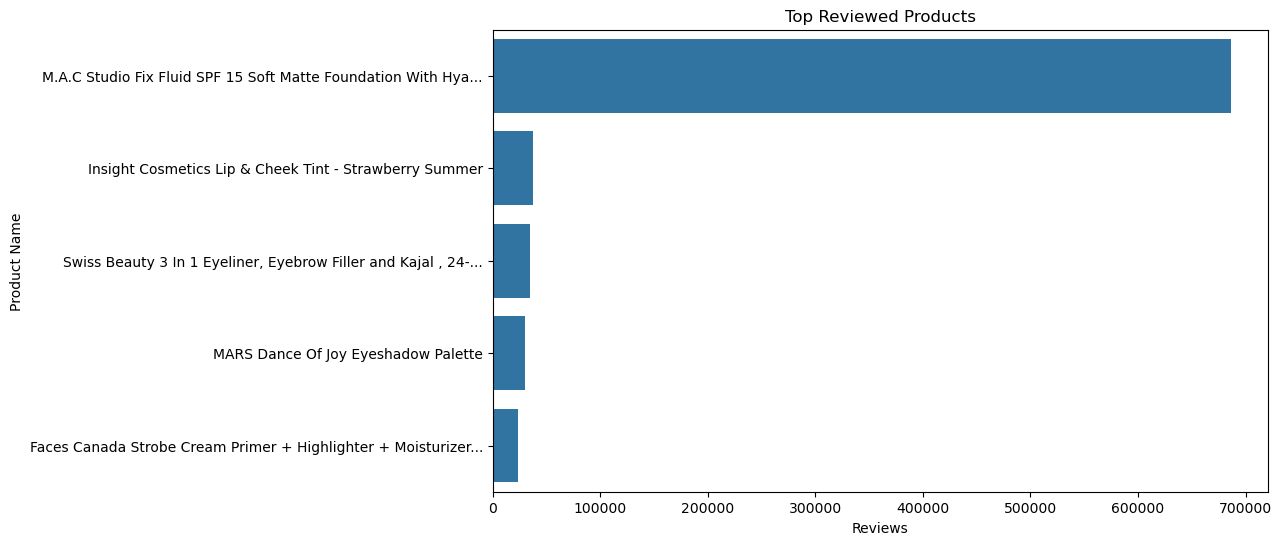

In [41]:
top_reviews = final_df.nlargest(10, "Reviews")

plt.figure(figsize=(10,6))
sns.barplot(data=top_reviews, x="Reviews", y="Product Name")
plt.title("Top Reviewed Products")
plt.show()

In [42]:
print(final_df.shape)
print(final_df.isnull().sum())
print(final_df.duplicated().sum())

(40, 6)
Product Name        0
Original Price      0
Discounted Price    0
Discount            0
Reviews             0
Category            0
dtype: int64
0


In [4]:
print(globals().keys())

dict_keys(['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__', '_ih', '_oh', '_dh', 'In', 'Out', 'get_ipython', 'exit', 'quit', 'open', '_', '__', '___', '__session__', '_i', '_ii', '_iii', '_i1', '_i2', '_i3', '_i4'])


In [5]:
dir()

['In',
 'Out',
 '_',
 '__',
 '___',
 '__builtin__',
 '__builtins__',
 '__doc__',
 '__loader__',
 '__name__',
 '__package__',
 '__session__',
 '__spec__',
 '_dh',
 '_i',
 '_i1',
 '_i2',
 '_i3',
 '_i4',
 '_i5',
 '_ih',
 '_ii',
 '_iii',
 '_oh',
 'exit',
 'get_ipython',
 'open',
 'quit']